# Proyecto Final IA — Análisis Comparativo con Escenarios

Este notebook integra el proyecto completo y agrega un **análisis por escenarios del hospital**. La idea no es forzar que Q-Learning supere a Value Iteration, sino demostrar cómo cambia el desempeño de ambos enfoques cuando el hospital se vuelve más congestionado, riesgoso o mixto.

**Comparación principal:**

- **Value Iteration:** método basado en modelo. Conoce las transiciones del MDP y calcula una política con la ecuación de Bellman.
- **Q-Learning:** método model-free. Aprende por experiencia mediante episodios, sin conocer directamente las probabilidades de transición.

**Métricas evaluadas:**

- Tiempo promedio de entrega.
- Consumo promedio de batería.
- Porcentaje de entregas exitosas.
- Recompensa acumulada promedio.
- Fallos de misión.

## 1. Configuración inicial

Esta sección importa librerías, configura rutas del repositorio y crea las carpetas donde se guardarán tablas y gráficas.

In [ ]:
from pathlib import Path
import sys
import random
import subprocess
import copy

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def find_project_root(start=None):
    """
    Busca automáticamente la raíz del repositorio.
    La raíz debe contener las carpetas src/ y tests/.
    """
    start = Path(start or Path.cwd()).resolve()

    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "tests").exists():
            return path

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. "
        "Asegúrate de abrir el notebook dentro del repositorio IA_Proyecto_Final."
    )


# Detectar raíz del proyecto
ROOT = find_project_root()

# Agregar raíz al path para poder importar src.environment, src.q_learning, etc.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Carpetas de salida
RESULTS_DIR = ROOT / "results"
plots_dir = RESULTS_DIR / "plots"
tables_dir = RESULTS_DIR / "tables"

plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Semilla base para resultados más comparables
random.seed(42)

print("Raíz del proyecto:", ROOT)
print("Carpeta de gráficas:", plots_dir.relative_to(ROOT))
print("Carpeta de tablas:", tables_dir.relative_to(ROOT))

Raíz del proyecto: c:\Users\viank\OneDrive\Desktop\S1_2026\IA_Proyecto_Final
Carpeta de gráficas: c:\Users\viank\OneDrive\Desktop\S1_2026\IA_Proyecto_Final\results\plots
Carpeta de tablas: c:\Users\viank\OneDrive\Desktop\S1_2026\IA_Proyecto_Final\results\tables


## 2. Validación con pruebas automatizadas

Antes de generar resultados, se ejecutan las pruebas unitarias. Esto ayuda a confirmar que el entorno y Q-Learning siguen funcionando después de cambios en el proyecto.

In [ ]:
result = subprocess.run(
    ["pytest", "tests/"],
    cwd=ROOT,
    text=True,
    capture_output=True
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

============================= test session starts =============================
platform win32 -- Python 3.13.7, pytest-9.0.3, pluggy-1.6.0
rootdir: c:\Users\viank\OneDrive\Desktop\S1_2026\IA_Proyecto_Final
plugins: anyio-4.13.0
collected 66 items

tests\test_environment.py ..............................                 [ 45%]
tests\test_q_learning.py ....................................            [100%]

============================= 66 passed in 4.38s ==============================



## 3. Importar módulos del proyecto

Se importan los archivos principales del repositorio:

- `environment.py`: define el hospital, acciones, batería, recompensas y transición estocástica.
- `value_iteration.py`: calcula la política óptima con Bellman.
- `q_learning.py`: entrena un agente mediante experiencia.
- `metrics.py`: evalúa y compara agentes.

In [ ]:
from src.environment import (
    HospitalEnvironment,
    Action,
    HOSPITAL_MAP,
    START_POS,
    GOAL_POS,
    CHARGE_POS,
    MAX_BATTERY,
    W, P, S, G, C, R, Z,
)
from src.value_iteration import ValueIterationAgent
from src.q_learning import QLearningAgent
from src.metrics import evaluate_agent, compare_agents, save_results_table

## 4. Revisión rápida del entorno base

Esta celda confirma que el robot inicia correctamente, cuál es el destino, cuál es la batería máxima y qué acciones puede tomar al inicio.

In [ ]:
env = HospitalEnvironment()
initial_state = env.reset()

print("Estado inicial:", initial_state)
print("Posición inicial esperada:", START_POS)
print("Destino:", GOAL_POS)
print("Estación de carga:", CHARGE_POS)
print("Batería máxima:", MAX_BATTERY)
print("Acciones posibles al inicio:", [a.name for a in env.get_possible_actions(initial_state)])

Estado inicial: (1, 1, 30)
Posición inicial esperada: (1, 1)
Destino: (10, 14)
Estación de carga: (5, 5)
Batería máxima: 30
Acciones posibles al inicio: ['UP', 'DOWN', 'LEFT', 'RIGHT', 'STAY']


## 5. Visualización del mapa del hospital

Se crea una función para dibujar el hospital. Los colores ayudan a identificar paredes, pasillos, zonas congestionadas, zonas de riesgo, estación de carga, inicio y destino.

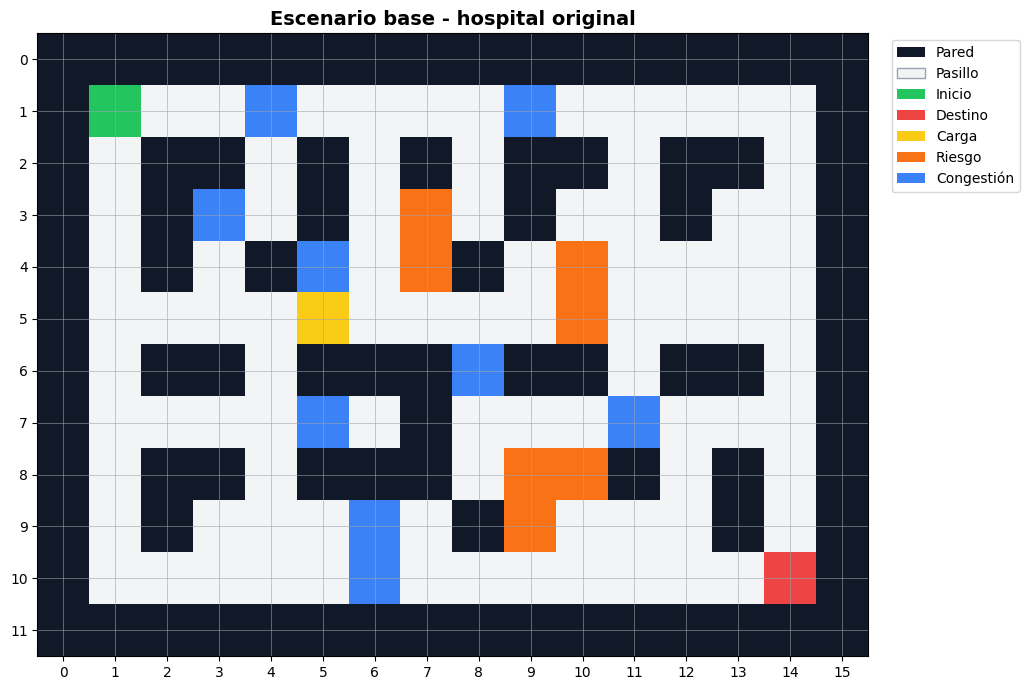

In [ ]:
cell_to_number = {
    W: 0,  # pared
    P: 1,  # pasillo
    S: 2,  # inicio
    G: 3,  # destino
    C: 4,  # carga
    R: 5,  # riesgo
    Z: 6,  # congestión
}

cell_colors = [
    "#111827",  # pared
    "#f3f4f6",  # pasillo
    "#22c55e",  # inicio
    "#ef4444",  # destino
    "#facc15",  # carga
    "#f97316",  # riesgo
    "#3b82f6",  # congestión
]

legend_items = [
    Patch(facecolor="#111827", label="Pared"),
    Patch(facecolor="#f3f4f6", edgecolor="#9ca3af", label="Pasillo"),
    Patch(facecolor="#22c55e", label="Inicio"),
    Patch(facecolor="#ef4444", label="Destino"),
    Patch(facecolor="#facc15", label="Carga"),
    Patch(facecolor="#f97316", label="Riesgo"),
    Patch(facecolor="#3b82f6", label="Congestión"),
]


def map_to_matrix(hospital_map):
    return [[cell_to_number[cell] for cell in row] for row in hospital_map]


def plot_hospital_map(env, title="Mapa del hospital", filename=None):
    matrix = map_to_matrix(env.map)
    cmap = ListedColormap(cell_colors)

    plt.figure(figsize=(11, 7))
    plt.imshow(matrix, cmap=cmap, vmin=0, vmax=6)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.grid(which="both", color="#9ca3af", linewidth=0.4)
    plt.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if filename:
        plt.savefig(plots_dir / filename, bbox_inches="tight", dpi=150)

    plt.show()


plot_hospital_map(env, "Escenario base - hospital original", "mapa_base.png")

## 6. Funciones auxiliares para escenarios

En lugar de modificar permanentemente `environment.py`, se crean escenarios dentro del notebook. Todos mantienen el mismo inicio, destino y estación de carga para que la comparación sea justa.

Escenarios propuestos:

1. **Base:** hospital original.
2. **Congestionado:** más celdas `Z`, simulando pasillos con más tráfico.
3. **Riesgo alto:** más celdas `R`, simulando zonas críticas o restringidas.
4. **Mixto:** combina congestión y riesgo para representar un hospital más complejo.

In [ ]:
def clone_base_map():
    return [row.copy() for row in HOSPITAL_MAP]


def apply_cell_changes(hospital_map, changes):
    """Aplica cambios de celdas sin tocar inicio, destino, carga ni paredes."""
    protected = {START_POS, GOAL_POS, CHARGE_POS}

    for cell_type, coordinates in changes.items():
        for row, col in coordinates:
            if (row, col) in protected:
                continue
            if hospital_map[row][col] == W:
                continue
            hospital_map[row][col] = cell_type

    return hospital_map


SCENARIO_CHANGES = {
    "Base": {},
    "Congestionado": {
        Z: [
            (1, 2), (1, 3), (1, 6), (1, 7),
            (5, 2), (5, 3), (5, 6), (5, 7),
            (7, 2), (7, 3),
            (10, 10), (10, 11), (10, 12),
        ]
    },
    "Riesgo alto": {
        R: [
            (3, 4), (4, 6),
            (5, 8), (5, 9),
            (7, 8), (7, 9),
            (9, 10),
            (10, 11), (10, 12), (10, 13),
        ]
    },
    "Mixto": {
        Z: [
            (1, 2), (1, 3), (1, 6), (1, 7),
            (5, 2), (5, 3), (7, 2), (7, 3),
            (10, 10), (10, 11),
        ],
        R: [
            (3, 4), (4, 6),
            (5, 8), (5, 9),
            (7, 8), (9, 10),
            (10, 12), (10, 13),
        ]
    },
}


def make_scenario_map(scenario_name):
    hospital_map = clone_base_map()
    changes = SCENARIO_CHANGES.get(scenario_name, {})
    return apply_cell_changes(hospital_map, changes)


def create_env_for_scenario(scenario_name):
    env = HospitalEnvironment()
    env.map = make_scenario_map(scenario_name)
    env.rows = len(env.map)
    env.cols = len(env.map[0])
    env.max_battery = MAX_BATTERY
    env.reset()
    return env

## 7. Visualización de escenarios

Estos mapas permiten explicar mejor el análisis. No se cambia la lógica de los algoritmos; solo se evalúa cómo responden ante diferentes condiciones del hospital.

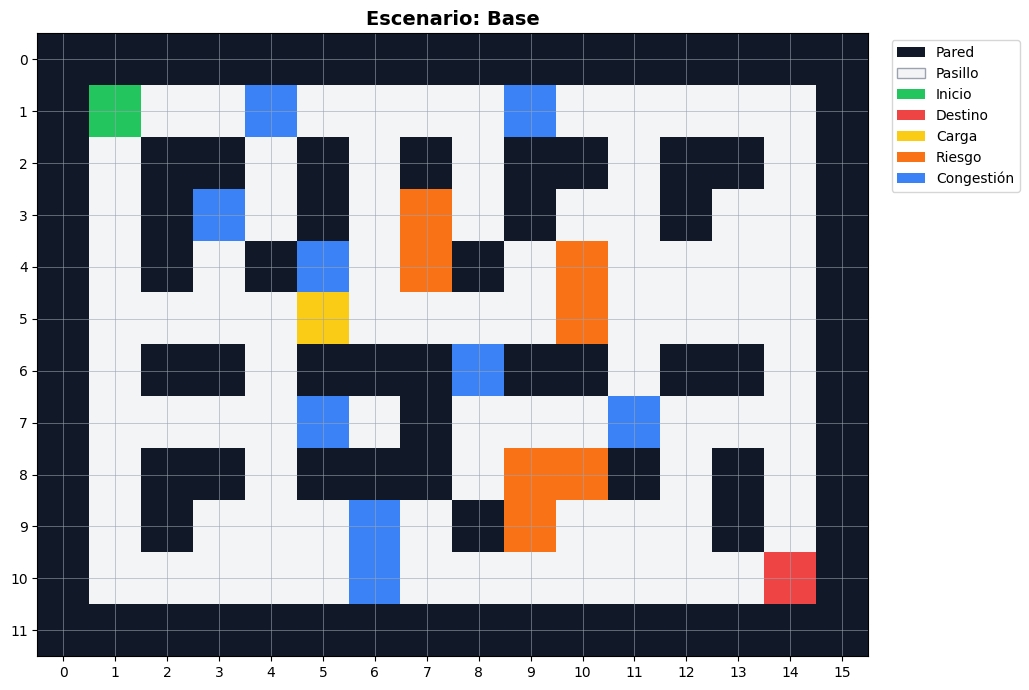

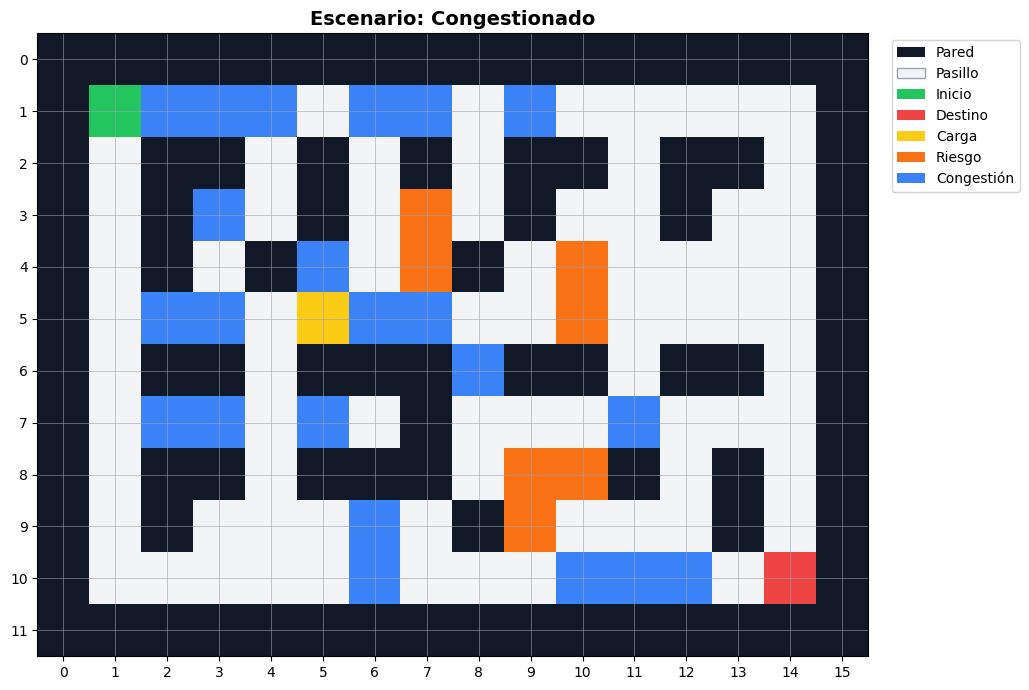

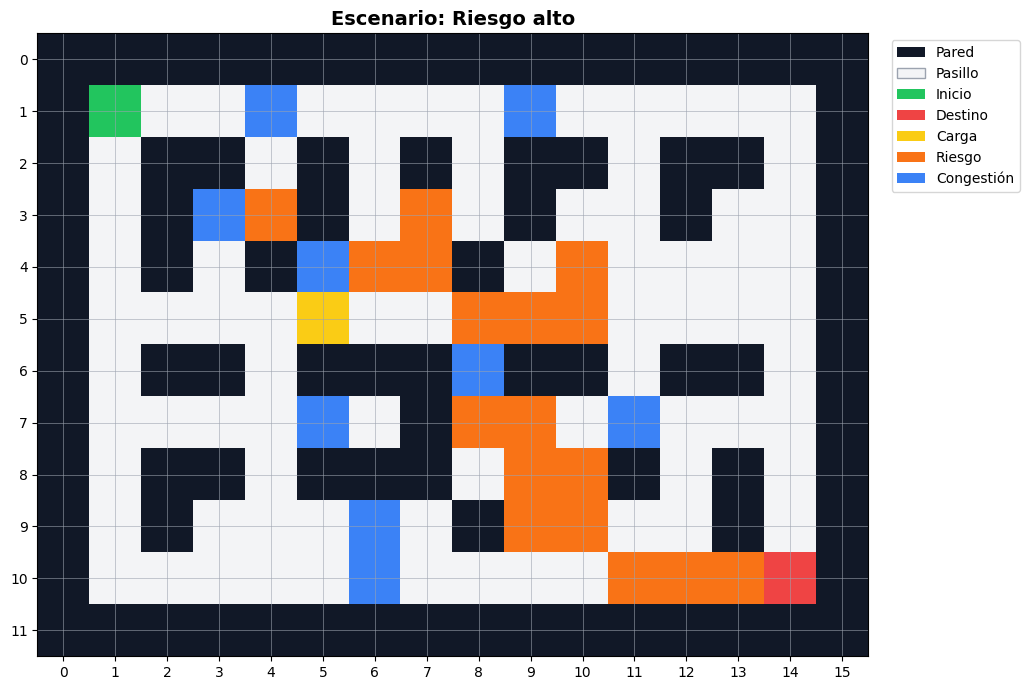

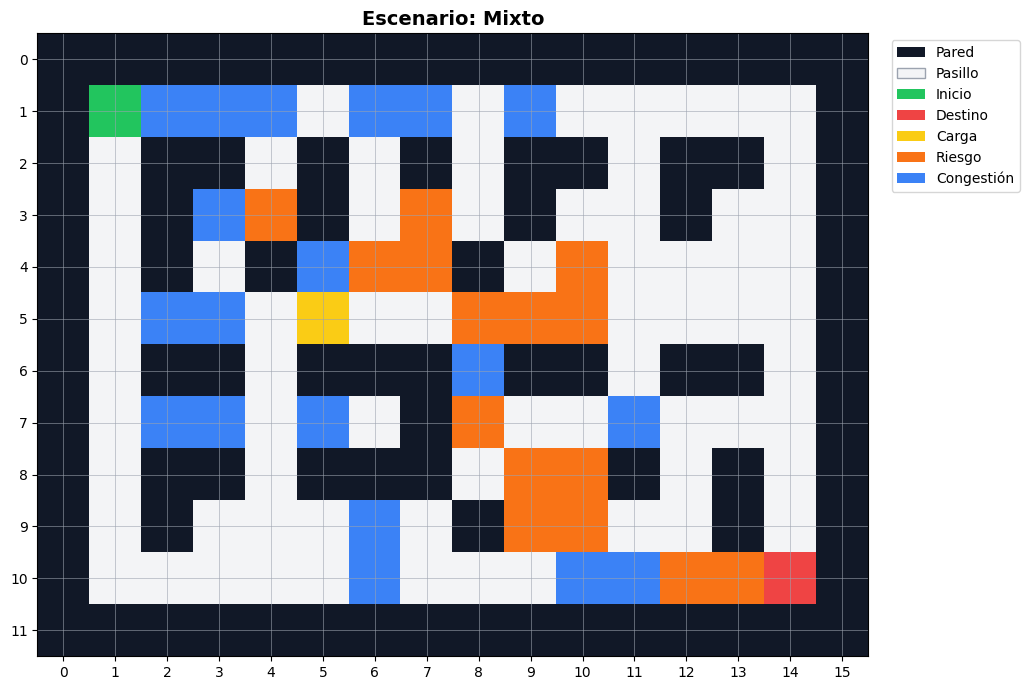

In [ ]:
for scenario_name in SCENARIO_CHANGES.keys():
    scenario_env = create_env_for_scenario(scenario_name)
    filename = f"mapa_{scenario_name.lower().replace(' ', '_')}.png"
    plot_hospital_map(scenario_env, f"Escenario: {scenario_name}", filename)

## 8. Funciones para entrenar y evaluar agentes

Estas funciones permiten correr Value Iteration y Q-Learning de forma ordenada. También se guarda información por episodio para analizar aprendizaje y resultados.

In [ ]:
def train_value_iteration(env, gamma=0.9, theta=1e-3, max_iterations=1000, verbose=False):
    agent = ValueIterationAgent(
        env,
        gamma=gamma,
        theta=theta,
        max_iterations=max_iterations
    )
    agent.run(verbose=verbose)
    return agent


def train_q_learning(env, episodes=50_000, alpha=0.1, gamma=0.95, epsilon=0.3, max_steps=200, seed=42):
    random.seed(seed)
    agent = QLearningAgent(
        env,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon
    )

    # Compatible con versiones del train que tienen o no tienen max_steps.
    try:
        agent.train(episodes=episodes, max_steps=max_steps)
    except TypeError:
        agent.train(episodes=episodes)

    return agent


def evaluate_model(env, agent, name, episodes=100, max_steps=200, seed=123):
    random.seed(seed)
    try:
        return evaluate_agent(env, agent, episodes=episodes, max_steps=max_steps, agent_name=name)
    except TypeError:
        return evaluate_agent(env, agent, episodes=episodes, agent_name=name)

## 9. Experimentos de Q-Learning en el escenario base

Primero se prueban varias configuraciones de Q-Learning en el escenario base. Esto permite observar si el agente mejora cuando se ajustan episodios, `gamma` o `epsilon`.

**Nota teórica:** no se espera que Q-Learning supere de forma estable a Value Iteration en este caso, porque Value Iteration conoce el modelo del entorno. Lo interesante es ver cuánto se acerca Q-Learning al aprender por experiencia.

In [ ]:
# Modo rápido para pruebas. Cambiar a False para una corrida final más fuerte.
FAST_MODE = False

if FAST_MODE:
    Q_BASE_EPISODES = 10_000
    Q_LONG_EPISODES = 20_000
else:
    Q_BASE_EPISODES = 50_000
    Q_LONG_EPISODES = 80_000

EVAL_EPISODES = 100
EVAL_MAX_STEPS = 200

q_experiment_configs = [
    {
        "name": "Q-Learning base",
        "episodes": Q_BASE_EPISODES,
        "alpha": 0.1,
        "gamma": 0.95,
        "epsilon": 0.30,
    },
    {
        "name": "Q-Learning más episodios",
        "episodes": Q_LONG_EPISODES,
        "alpha": 0.1,
        "gamma": 0.95,
        "epsilon": 0.30,
    },
    {
        "name": "Q-Learning gamma alto",
        "episodes": Q_LONG_EPISODES,
        "alpha": 0.1,
        "gamma": 0.98,
        "epsilon": 0.30,
    },
    {
        "name": "Q-Learning más explotación",
        "episodes": Q_LONG_EPISODES,
        "alpha": 0.1,
        "gamma": 0.98,
        "epsilon": 0.15,
    },
]

q_experiment_results = []
q_agents = {}

for config in q_experiment_configs:
    print("Entrenando:", config["name"])
    env_q = create_env_for_scenario("Base")
    agent_q = train_q_learning(
        env_q,
        episodes=config["episodes"],
        alpha=config["alpha"],
        gamma=config["gamma"],
        epsilon=config["epsilon"],
        max_steps=EVAL_MAX_STEPS,
        seed=42,
    )

    result_q = evaluate_model(
        env_q,
        agent_q,
        name=config["name"],
        episodes=EVAL_EPISODES,
        max_steps=EVAL_MAX_STEPS,
        seed=123,
    )

    result_q["config"] = config
    q_experiment_results.append(result_q)
    q_agents[config["name"]] = agent_q

q_experiment_table = compare_agents(*q_experiment_results)
q_experiment_table["Tiempo promedio de entrega"] = q_experiment_table["Tiempo promedio de entrega"].round(2)
q_experiment_table["Consumo promedio de batería"] = q_experiment_table["Consumo promedio de batería"].round(2)
q_experiment_table["% entregas exitosas"] = q_experiment_table["% entregas exitosas"].round(1)
q_experiment_table["Recompensa acumulada promedio"] = q_experiment_table["Recompensa acumulada promedio"].round(2)

q_experiment_table

Entrenando: Q-Learning base
Entrenando: Q-Learning más episodios
Entrenando: Q-Learning gamma alto
Entrenando: Q-Learning más explotación


,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Q-Learning base,100,30.98,29.55,66.0,11.16,34
1,Q-Learning más episodios,100,30.08,28.96,77.0,28.45,23
2,Q-Learning gamma alto,100,32.97,29.59,64.0,4.12,36
3,Q-Learning más explotación,100,32.56,28.04,91.0,47.11,9


## 10. Elegir la mejor configuración de Q-Learning

Se selecciona automáticamente la mejor configuración de Q-Learning usando como prioridad:

1. Mayor porcentaje de entregas exitosas.
2. Mayor recompensa acumulada promedio.
3. Menor cantidad de fallos.

In [ ]:
best_q_index = q_experiment_table.sort_values(
    by=["% entregas exitosas", "Recompensa acumulada promedio", "Fallos de misión"],
    ascending=[False, False, True]
).index[0]

best_q_name = q_experiment_table.loc[best_q_index, "Agente"]
best_q_config = next(r["config"] for r in q_experiment_results if r["agent"] == best_q_name)

print("Mejor configuración Q-Learning:", best_q_name)
print(best_q_config)

Mejor configuración Q-Learning: Q-Learning más explotación
{'name': 'Q-Learning más explotación', 'episodes': 80000, 'alpha': 0.1, 'gamma': 0.98, 'epsilon': 0.15}


## 11. Curva de aprendizaje de la mejor configuración Q-Learning

Esta gráfica es importante porque muestra que Q-Learning aprende mediante experiencia. La línea suave representa un promedio móvil para observar la tendencia general.

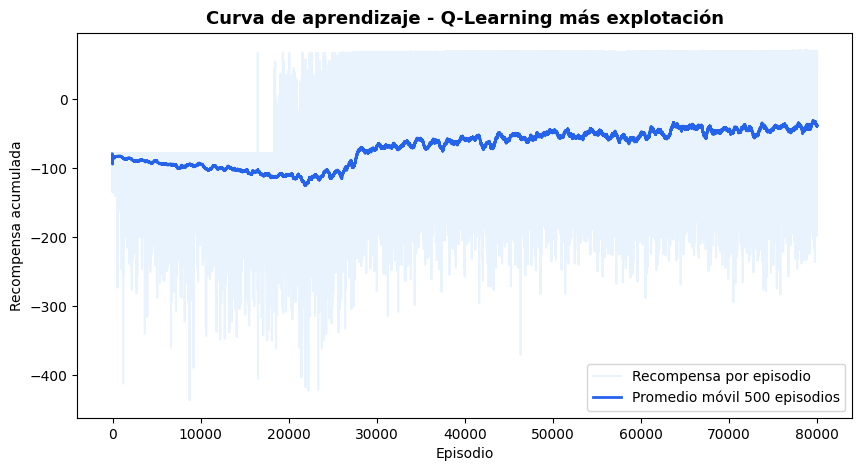

In [ ]:
best_q_agent = q_agents[best_q_name]

rewards = pd.Series(best_q_agent.rewards_per_episode)
rolling_rewards = rewards.rolling(window=500, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.20, color="#0f7826", label="Recompensa por episodio")
plt.plot(rolling_rewards, color="#2563eb", linewidth=2, label="Promedio móvil 500 episodios")
plt.title(f"Curva de aprendizaje - {best_q_name}", fontsize=13, fontweight="bold")
plt.xlabel("Episodio")
plt.ylabel("Recompensa acumulada")
plt.legend()
plt.savefig(plots_dir / "q_learning_mejor_curva_aprendizaje.png", bbox_inches="tight", dpi=150)
plt.show()

## 12. Comparación principal en escenario base

Ahora se compara Value Iteration contra la mejor configuración encontrada de Q-Learning en el escenario base.

In [ ]:
env_vi_base = create_env_for_scenario("Base")
vi_agent_base = train_value_iteration(env_vi_base, gamma=0.9, theta=1e-3, verbose=True)

result_vi_base = evaluate_model(
    env_vi_base,
    vi_agent_base,
    name="Value Iteration",
    episodes=EVAL_EPISODES,
    max_steps=EVAL_MAX_STEPS,
    seed=123,
)

# Reentrenar mejor Q-Learning para comparación limpia.
env_q_base = create_env_for_scenario("Base")
best_q_agent_base = train_q_learning(
    env_q_base,
    episodes=best_q_config["episodes"],
    alpha=best_q_config["alpha"],
    gamma=best_q_config["gamma"],
    epsilon=best_q_config["epsilon"],
    max_steps=EVAL_MAX_STEPS,
    seed=42,
)

result_q_base = evaluate_model(
    env_q_base,
    best_q_agent_base,
    name=best_q_name,
    episodes=EVAL_EPISODES,
    max_steps=EVAL_MAX_STEPS,
    seed=123,
)

base_comparison = compare_agents(result_vi_base, result_q_base)
base_comparison["Tiempo promedio de entrega"] = base_comparison["Tiempo promedio de entrega"].round(2)
base_comparison["Consumo promedio de batería"] = base_comparison["Consumo promedio de batería"].round(2)
base_comparison["% entregas exitosas"] = base_comparison["% entregas exitosas"].round(1)
base_comparison["Recompensa acumulada promedio"] = base_comparison["Recompensa acumulada promedio"].round(2)

save_results_table(base_comparison, tables_dir / "metricas_base_vi_vs_mejor_q_learning.csv")
base_comparison

Iter   10  Δ = 19.371024
Iter   20  Δ = 2.927521
Iter   30  Δ = 0.306108
Iter   40  Δ = 0.083290
Iter   50  Δ = 0.001963
Convergió en 52 iteraciones (Δ = 0.000942)


,Agente,Episodios,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Value Iteration,100,28.98,26.00,90.0,48.60,10
1,Q-Learning más explotación,100,32.56,28.04,91.0,47.11,9


## 13. Gráficas comparativas del escenario base

Se generan gráficas con colores consistentes para comparar ambos agentes.

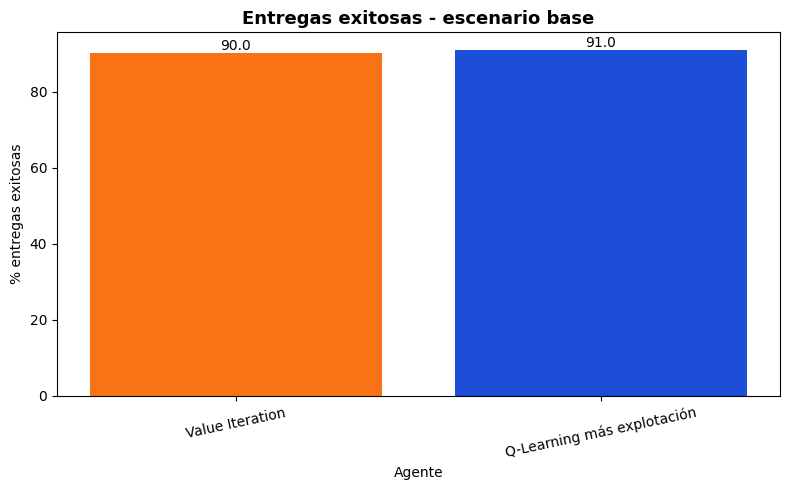

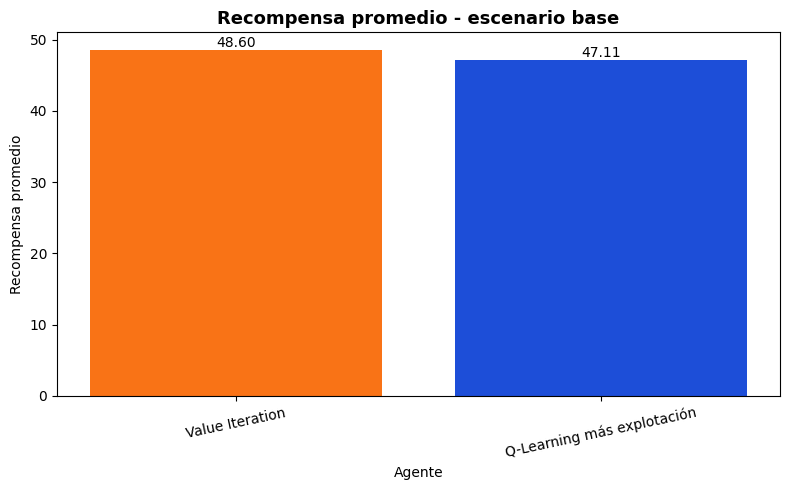

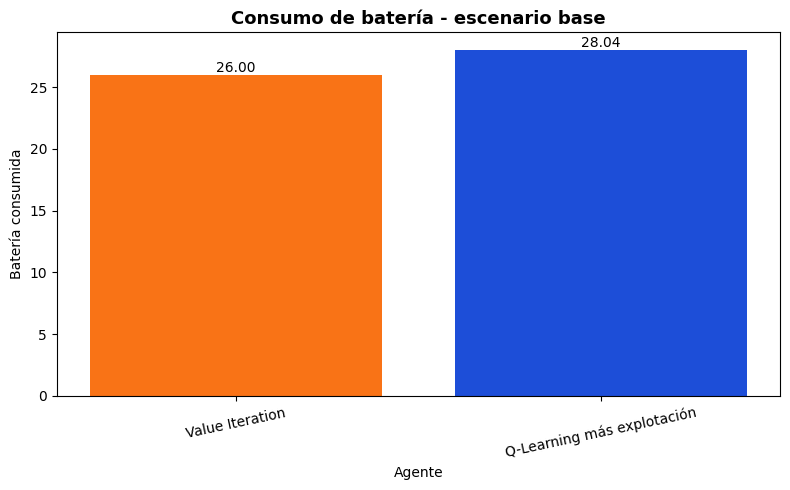

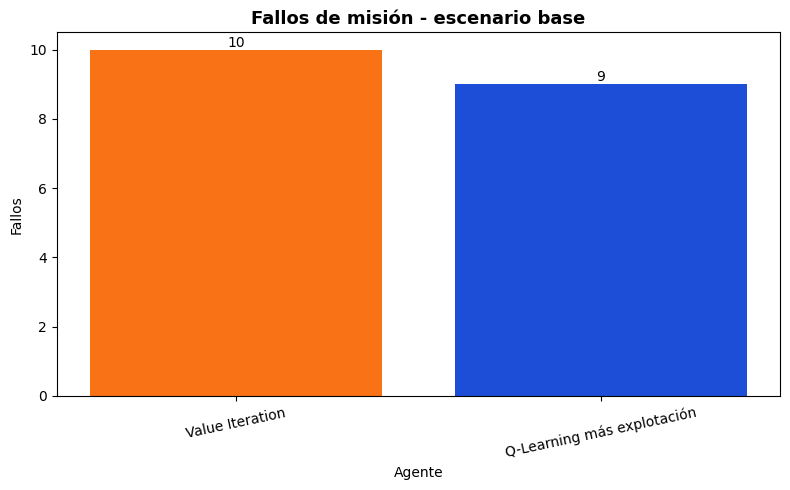

In [ ]:
agent_colors = {
    "Value Iteration": "#f97316",
    best_q_name: "#2563eb",
    "Q-Learning base": "#60a5fa",
    "Q-Learning más episodios": "#3b82f6",
    "Q-Learning gamma alto": "#2563eb",
    "Q-Learning más explotación": "#1d4ed8",
}


def save_bar_chart(df, column, title, ylabel, filename, decimals=2):
    data = df.copy()
    values = data[column].fillna(0)
    colors = [agent_colors.get(agent, "#6b7280") for agent in data["Agente"]]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(data["Agente"], values, color=colors)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.ylabel(ylabel)
    plt.xlabel("Agente")
    plt.xticks(rotation=12)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.savefig(plots_dir / filename, bbox_inches="tight", dpi=150)
    plt.show()


save_bar_chart(
    base_comparison,
    "% entregas exitosas",
    "Entregas exitosas - escenario base",
    "% entregas exitosas",
    "base_entregas_exitosas.png",
    decimals=1,
)

save_bar_chart(
    base_comparison,
    "Recompensa acumulada promedio",
    "Recompensa promedio - escenario base",
    "Recompensa promedio",
    "base_recompensa_promedio.png",
    decimals=2,
)

save_bar_chart(
    base_comparison,
    "Consumo promedio de batería",
    "Consumo de batería - escenario base",
    "Batería consumida",
    "base_consumo_bateria.png",
    decimals=2,
)

save_bar_chart(
    base_comparison,
    "Fallos de misión",
    "Fallos de misión - escenario base",
    "Fallos",
    "base_fallos_mision.png",
    decimals=0,
)

## 14. Análisis por escenarios del hospital

En esta sección se evalúa la robustez de los algoritmos. Se usa la mejor configuración de Q-Learning encontrada en el escenario base y se compara contra Value Iteration en varios mapas.

Esto permite responder una pregunta más fuerte para el proyecto:

> ¿Qué tan estable es cada enfoque cuando cambian las condiciones del hospital?

In [ ]:
scenario_results = []

for scenario_name in SCENARIO_CHANGES.keys():
    print("Evaluando escenario:", scenario_name)

    # Value Iteration
    env_vi = create_env_for_scenario(scenario_name)
    vi_agent = train_value_iteration(env_vi, gamma=0.9, theta=1e-3, verbose=False)
    vi_result = evaluate_model(
        env_vi,
        vi_agent,
        name="Value Iteration",
        episodes=EVAL_EPISODES,
        max_steps=EVAL_MAX_STEPS,
        seed=123,
    )
    vi_result["scenario"] = scenario_name
    scenario_results.append(vi_result)

    # Q-Learning con la mejor configuración encontrada
    env_q = create_env_for_scenario(scenario_name)
    q_agent = train_q_learning(
        env_q,
        episodes=best_q_config["episodes"],
        alpha=best_q_config["alpha"],
        gamma=best_q_config["gamma"],
        epsilon=best_q_config["epsilon"],
        max_steps=EVAL_MAX_STEPS,
        seed=42,
    )
    q_result = evaluate_model(
        env_q,
        q_agent,
        name=best_q_name,
        episodes=EVAL_EPISODES,
        max_steps=EVAL_MAX_STEPS,
        seed=123,
    )
    q_result["scenario"] = scenario_name
    scenario_results.append(q_result)

scenario_rows = []
for result in scenario_results:
    scenario_rows.append({
        "Escenario": result["scenario"],
        "Agente": result["agent"],
        "Episodios evaluación": result["episodes"],
        "Tiempo promedio de entrega": result["avg_delivery_time"],
        "Consumo promedio de batería": result["avg_battery_consumption"],
        "% entregas exitosas": result["success_rate"],
        "Recompensa acumulada promedio": result["avg_reward"],
        "Fallos de misión": result["mission_failures"],
    })

scenario_table = pd.DataFrame(scenario_rows)
scenario_table["Tiempo promedio de entrega"] = scenario_table["Tiempo promedio de entrega"].round(2)
scenario_table["Consumo promedio de batería"] = scenario_table["Consumo promedio de batería"].round(2)
scenario_table["% entregas exitosas"] = scenario_table["% entregas exitosas"].round(1)
scenario_table["Recompensa acumulada promedio"] = scenario_table["Recompensa acumulada promedio"].round(2)

scenario_table.to_csv(
    tables_dir / "comparacion_por_escenario.csv",
    index=False,
    encoding="utf-8-sig"
)

scenario_table

Evaluando escenario: Base
Evaluando escenario: Congestionado
Evaluando escenario: Riesgo alto
Evaluando escenario: Mixto


,Escenario,Agente,Episodios evaluación,Tiempo promedio de entrega,Consumo promedio de batería,% entregas exitosas,Recompensa acumulada promedio,Fallos de misión
0,Base,Value Iteration,100,28.98,26.00,90.0,48.60,10
1,Base,Q-Learning más explotación,100,32.56,28.04,91.0,47.11,9
2,Congestionado,Value Iteration,100,29.40,26.97,80.0,19.79,20
3,Congestionado,Q-Learning más explotación,100,30.83,29.24,65.0,-6.34,35
4,Riesgo alto,Value Iteration,100,NaN,24.00,0.0,-200.00,100
5,Riesgo alto,Q-Learning más explotación,100,32.89,29.48,71.0,12.50,29
6,Mixto,Value Iteration,100,75.68,23.25,82.0,-58.79,18
7,Mixto,Q-Learning más explotación,100,32.82,28.46,73.0,-30.77,27


## 15. Gráficas por escenario

Estas gráficas permiten observar cómo cambia el desempeño por tipo de hospital.

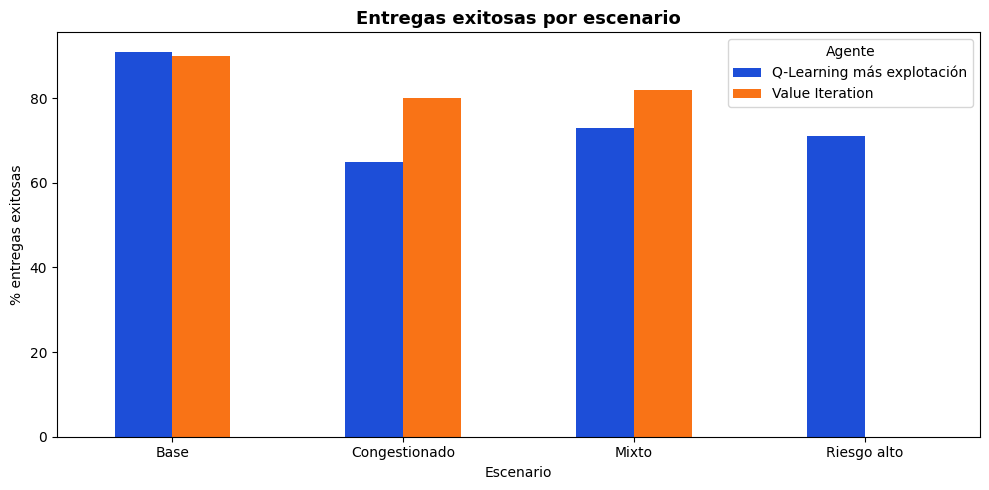

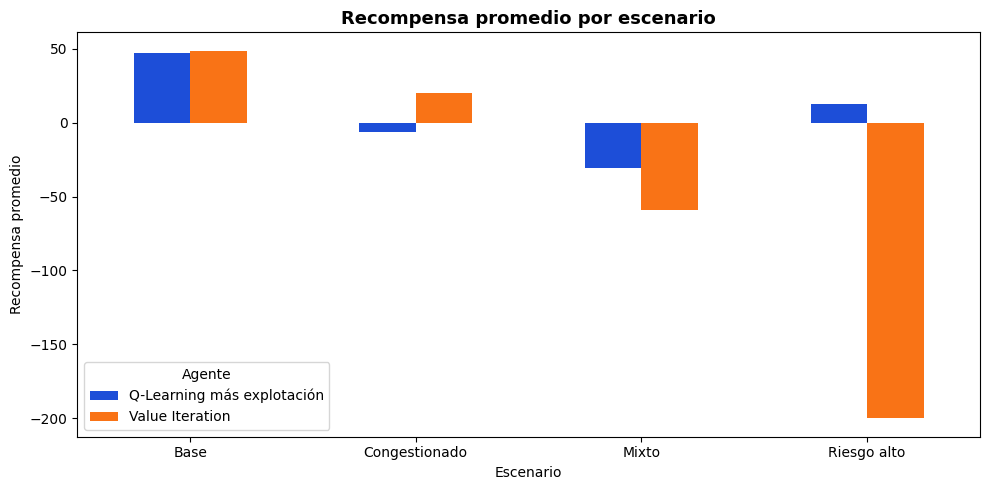

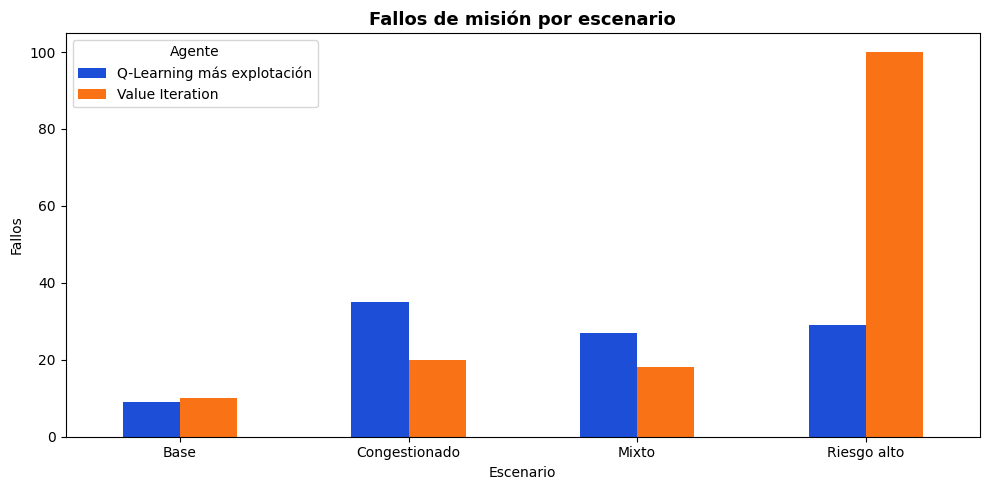

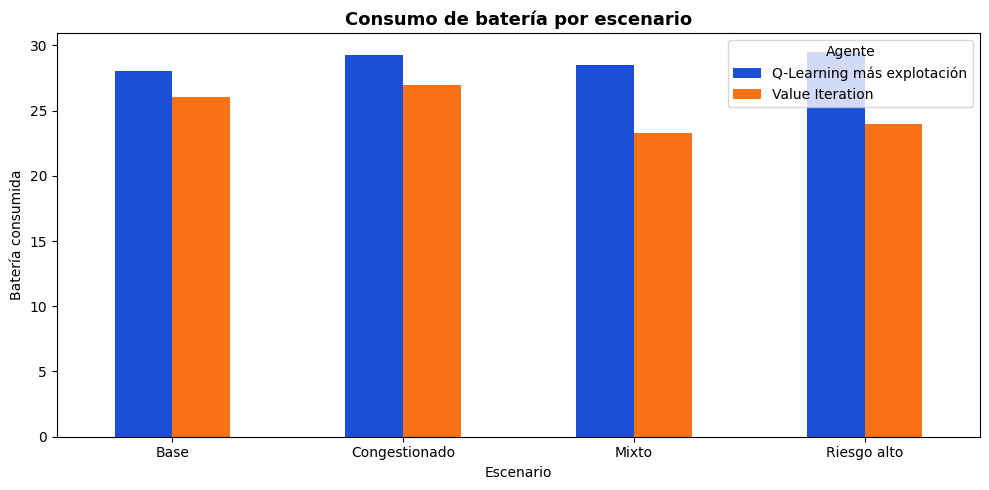

In [ ]:
def plot_grouped_bars(df, metric, title, ylabel, filename):
    pivot = df.pivot(index="Escenario", columns="Agente", values=metric)

    ax = pivot.plot(
        kind="bar",
        figsize=(10, 5),
        color=[agent_colors.get(col, "#6b7280") for col in pivot.columns]
    )

    plt.title(title, fontsize=13, fontweight="bold")
    plt.ylabel(ylabel)
    plt.xlabel("Escenario")
    plt.xticks(rotation=0)
    plt.legend(title="Agente")
    plt.tight_layout()
    plt.savefig(plots_dir / filename, bbox_inches="tight", dpi=150)
    plt.show()


plot_grouped_bars(
    scenario_table,
    "% entregas exitosas",
    "Entregas exitosas por escenario",
    "% entregas exitosas",
    "escenarios_entregas_exitosas.png",
)

plot_grouped_bars(
    scenario_table,
    "Recompensa acumulada promedio",
    "Recompensa promedio por escenario",
    "Recompensa promedio",
    "escenarios_recompensa_promedio.png",
)

plot_grouped_bars(
    scenario_table,
    "Fallos de misión",
    "Fallos de misión por escenario",
    "Fallos",
    "escenarios_fallos_mision.png",
)

plot_grouped_bars(
    scenario_table,
    "Consumo promedio de batería",
    "Consumo de batería por escenario",
    "Batería consumida",
    "escenarios_consumo_bateria.png",
)

## 16. Ganador por métrica y escenario

Esta tabla resume qué agente tuvo mejor desempeño por métrica en cada escenario.

In [ ]:
winner_rows = []

for scenario_name in scenario_table["Escenario"].unique():
    subset = scenario_table[scenario_table["Escenario"] == scenario_name].copy()

    metrics_rules = [
        ("Tiempo promedio de entrega", "Menor"),
        ("Consumo promedio de batería", "Menor"),
        ("% entregas exitosas", "Mayor"),
        ("Recompensa acumulada promedio", "Mayor"),
        ("Fallos de misión", "Menor"),
    ]

    for metric, criterion in metrics_rules:
        if criterion == "Mayor":
            winner = subset.loc[subset[metric].idxmax(), "Agente"]
        else:
            winner = subset.loc[subset[metric].idxmin(), "Agente"]

        winner_rows.append({
            "Escenario": scenario_name,
            "Métrica": metric,
            "Mejor resultado": criterion,
            "Ganador": winner,
        })

winner_table = pd.DataFrame(winner_rows)
winner_table.to_csv(
    tables_dir / "ganador_por_metrica_y_escenario.csv",
    index=False,
    encoding="utf-8-sig"
)

winner_table

,Escenario,Métrica,Mejor resultado,Ganador
0,Base,Tiempo promedio de entrega,Menor,Value Iteration
1,Base,Consumo promedio de batería,Menor,Value Iteration
2,Base,% entregas exitosas,Mayor,Q-Learning más explotación
3,Base,Recompensa acumulada promedio,Mayor,Value Iteration
4,Base,Fallos de misión,Menor,Q-Learning más explotación
5,Congestionado,Tiempo promedio de entrega,Menor,Value Iteration
6,Congestionado,Consumo promedio de batería,Menor,Value Iteration
7,Congestionado,% entregas exitosas,Mayor,Value Iteration
8,Congestionado,Recompensa acumulada promedio,Mayor,Value Iteration
9,Congestionado,Fallos de misión,Menor,Value Iteration


## 17. Puntaje general normalizado

Este puntaje es solo una ayuda visual para resumir desempeño. No reemplaza las métricas reales. Se normalizan las métricas para que todas queden en escala 0 a 1:

- Mayor éxito es mejor.
- Mayor recompensa es mejor.
- Menor consumo de batería es mejor.
- Menor cantidad de fallos es mejor.

In [ ]:
def minmax(series):
    if series.max() == series.min():
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - series.min()) / (series.max() - series.min())

score_table = scenario_table.copy()

score_table["Éxito normalizado"] = score_table["% entregas exitosas"] / 100
score_table["Recompensa normalizada"] = minmax(score_table["Recompensa acumulada promedio"])
score_table["Batería normalizada"] = 1 - minmax(score_table["Consumo promedio de batería"])
score_table["Fallos normalizados"] = 1 - minmax(score_table["Fallos de misión"])

score_columns = [
    "Éxito normalizado",
    "Recompensa normalizada",
    "Batería normalizada",
    "Fallos normalizados",
]

score_table["Puntaje general"] = score_table[score_columns].mean(axis=1)
score_table["Puntaje general"] = score_table["Puntaje general"].round(3)

score_table.to_csv(
    tables_dir / "puntaje_general_por_escenario.csv",
    index=False,
    encoding="utf-8-sig"
)

score_table[["Escenario", "Agente", "Puntaje general"] + score_columns]

,Escenario,Agente,Puntaje general,Éxito normalizado,Recompensa normalizada,Batería normalizada,Fallos normalizados
0,Base,Value Iteration,0.862,0.90,1.000000,0.558587,0.989011
1,Base,Q-Learning más explotación,0.784,0.91,0.994006,0.231140,1.000000
2,Congestionado,Value Iteration,0.742,0.80,0.884111,0.402889,0.879121
3,Congestionado,Q-Learning más explotación,0.545,0.65,0.779002,0.038523,0.714286
4,Riesgo alto,Value Iteration,0.220,0.00,0.000000,0.879615,0.000000
5,Riesgo alto,Q-Learning más explotación,0.586,0.71,0.854787,0.000000,0.780220
6,Mixto,Value Iteration,0.822,0.82,0.568021,1.000000,0.901099
7,Mixto,Q-Learning más explotación,0.594,0.73,0.680732,0.163724,0.802198


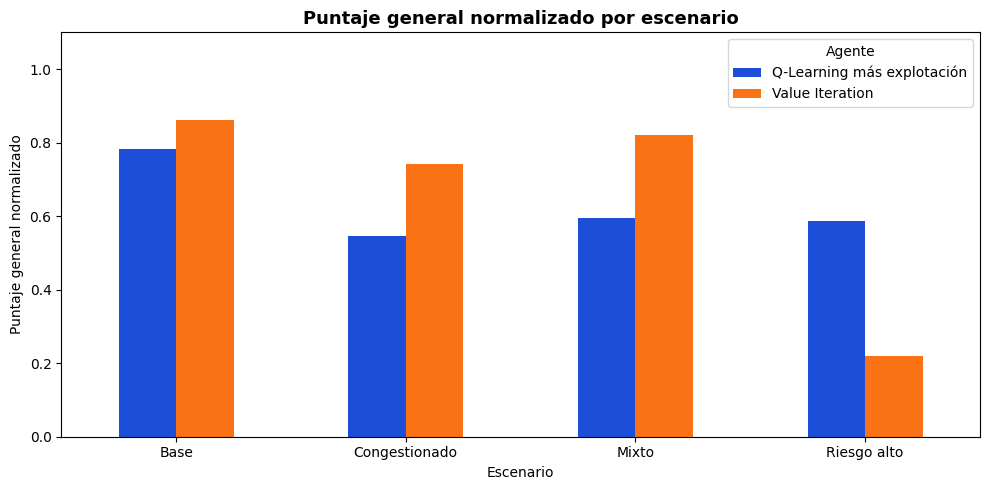

In [ ]:
pivot_score = score_table.pivot(index="Escenario", columns="Agente", values="Puntaje general")

pivot_score.plot(
    kind="bar",
    figsize=(10, 5),
    color=[agent_colors.get(col, "#6b7280") for col in pivot_score.columns]
)

plt.title("Puntaje general normalizado por escenario", fontsize=13, fontweight="bold")
plt.ylabel("Puntaje general normalizado")
plt.xlabel("Escenario")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Agente")
plt.tight_layout()
plt.savefig(plots_dir / "puntaje_general_por_escenario.png", bbox_inches="tight", dpi=150)
plt.show()

## 18. Interpretación automática de resultados

Esta celda genera texto base que se puede usar en el informe o presentación.

In [ ]:
print("Interpretación sugerida para el informe:")

base_vi = scenario_table[(scenario_table["Escenario"] == "Base") & (scenario_table["Agente"] == "Value Iteration")].iloc[0]
base_q = scenario_table[(scenario_table["Escenario"] == "Base") & (scenario_table["Agente"] == best_q_name)].iloc[0]

print(f"En el escenario base, Value Iteration obtuvo {base_vi['% entregas exitosas']:.1f}% de entregas exitosas, ")
print(f"mientras que {best_q_name} obtuvo {base_q['% entregas exitosas']:.1f}%.")

print("Value Iteration suele obtener mejores resultados porque utiliza un modelo conocido del entorno y calcula la política con la ecuación de Bellman.")
print("Q-Learning, en cambio, aprende mediante experiencia; por eso puede cometer más errores durante el entrenamiento y requiere más episodios para mejorar su política.")

best_q_success = q_experiment_table["% entregas exitosas"].max()
print(f"Las pruebas adicionales muestran que Q-Learning sí puede mejorar con ajuste de parámetros: la mejor configuración alcanzó {best_q_success:.1f}% de entregas exitosas en el escenario base.")

print("El análisis por escenarios permite observar la robustez de cada enfoque ante mayor congestión, zonas de riesgo y condiciones mixtas del hospital.")
print("Si Value Iteration mantiene mejor desempeño en varios escenarios, se concluye que es más estable cuando el modelo del entorno está disponible.")
print("Si Q-Learning mejora en algunos escenarios, se puede destacar que es útil cuando no se conocen las transiciones y el agente debe aprender directamente de la experiencia.")

Interpretación sugerida para el informe:
En el escenario base, Value Iteration obtuvo 90.0% de entregas exitosas, 
mientras que Q-Learning más explotación obtuvo 91.0%.
Value Iteration suele obtener mejores resultados porque utiliza un modelo conocido del entorno y calcula la política con la ecuación de Bellman.
Q-Learning, en cambio, aprende mediante experiencia; por eso puede cometer más errores durante el entrenamiento y requiere más episodios para mejorar su política.
Las pruebas adicionales muestran que Q-Learning sí puede mejorar con ajuste de parámetros: la mejor configuración alcanzó 91.0% de entregas exitosas en el escenario base.
El análisis por escenarios permite observar la robustez de cada enfoque ante mayor congestión, zonas de riesgo y condiciones mixtas del hospital.
Si Value Iteration mantiene mejor desempeño en varios escenarios, se concluye que es más estable cuando el modelo del entorno está disponible.
Si Q-Learning mejora en algunos escenarios, se puede destacar q

## 19. Archivos generados

Al ejecutar este notebook se generan archivos en:

```text
results/
├── plots/
│   ├── mapa_base.png
│   ├── mapa_congestionado.png
│   ├── mapa_riesgo_alto.png
│   ├── mapa_mixto.png
│   ├── q_learning_mejor_curva_aprendizaje.png
│   ├── base_entregas_exitosas.png
│   ├── escenarios_entregas_exitosas.png
│   ├── escenarios_recompensa_promedio.png
│   ├── escenarios_fallos_mision.png
│   └── puntaje_general_por_escenario.png
│
└── tables/
    ├── metricas_base_vi_vs_mejor_q_learning.csv
    ├── comparacion_por_escenario.csv
    ├── ganador_por_metrica_y_escenario.csv
    └── puntaje_general_por_escenario.csv
```

Estos archivos pueden usarse para el informe, presentación y anexos.